# 02. 코호트 잔존율 분석

유저의 **첫 활동(view 포함) 월**을 코호트로 삼아, 코호트 이후 경과 개월별 잔존율을
히트맵으로 확인한다.

**메모리 전략**: 원본 이벤트 수(7개월 합 수억 건)를 그대로 다루지 않고, 달마다 `user_id`
컬럼만 읽어 그 달의 고유 활동 유저 목록만 추출한다. 코호트/잔존율 계산에는 "누가 그 달에
활동했는지"만 필요하고 개별 이벤트 시각은 필요 없기 때문에, 이 방식으로 7개월 전체를
가볍게 처리할 수 있다.

In [8]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import config
from src import load

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.rcParams["font.family"] = "AppleGothic"  # 맥북 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 1. 월별 고유 활동 유저 추출

7개 파일을 순서대로 스캔하며 `user_id`만 읽어 그 달의 고유 유저 목록을 뽑는다.

In [9]:
month_labels = ["2019-10", "2019-11", "2019-12", "2020-01", "2020-02", "2020-03", "2020-04"]
month_paths = config.RAW_PATHS  # month_labels와 동일한 순서

monthly_users = {}
for label, path in zip(month_labels, month_paths):
    users = load.load_month(path, usecols=["user_id"])["user_id"].unique()
    monthly_users[label] = users
    print(f"{label}: 고유 유저 {len(users):,}명 ({len(users) / 1000:.2f}만 명)")

2019-10: 고유 유저 3,022,290명 (3022.29만 명)
2019-11: 고유 유저 3,696,117명 (3696.12만 명)
2019-12: 고유 유저 4,577,232명 (4577.23만 명)
2020-01: 고유 유저 4,385,985명 (4385.98만 명)
2020-02: 고유 유저 4,233,206명 (4233.21만 명)
2020-03: 고유 유저 4,114,060명 (4114.06만 명)
2020-04: 고유 유저 4,509,623명 (4509.62만 명)


## 2. 코호트 배정 & 경과 개월 계산

각 (유저, 활동월) 쌍을 long 포맷으로 모으고, 유저별 첫 활동월을 코호트로 지정한 뒤
경과 개월(period_number = 활동월 인덱스 - 코호트월 인덱스)을 계산한다.

In [10]:
month_to_idx = {label: i for i, label in enumerate(month_labels)}

activity_long = pd.concat(
    [pd.DataFrame({"user_id": users, "month_idx": month_to_idx[label]}) for label, users in monthly_users.items()],
    ignore_index=True,
)
del monthly_users

mem_mb = activity_long.memory_usage(deep=True).sum() / 1e6
print(f"activity_long: {activity_long.shape[0]:,} rows, {mem_mb:,.1f} MB")

cohort_idx = activity_long.groupby("user_id")["month_idx"].transform("min")
activity_long["period_number"] = activity_long["month_idx"] - cohort_idx
activity_long["cohort_idx"] = cohort_idx

activity_long: 28,538,513 rows, 456.6 MB


## 3. 코호트별 잔존 유저 수 & 잔존율

코호트(cohort_idx) × 경과 개월(period_number)별 고유 유저 수를 피벗하고, 각 코호트의
0개월차(가입 시점) 인원 대비 비율로 잔존율을 계산한다.

In [11]:
cohort_counts = (
    activity_long.groupby(["cohort_idx", "period_number"])["user_id"]
    .nunique()
    .unstack()  # 관측되지 않은(미래) 조합은 0이 아니라 NaN으로 남겨 실제 0%와 구분
)

idx_to_month = {i: label for label, i in month_to_idx.items()}
cohort_counts.index = cohort_counts.index.map(idx_to_month)
cohort_counts.index.name = "cohort_month"

cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

cohort_counts

period_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2019-10,3022290.0,1401758.0,1215865.0,980892.0,888766.0,792909.0,719230.0
2019-11,2294359.0,821378.0,596093.0,523666.0,457858.0,409538.0,NaN
2019-12,2539989.0,663253.0,488519.0,405193.0,350488.0,NaN,NaN
2020-01,2145747.0,494676.0,354566.0,294152.0,NaN,NaN,NaN
2020-02,1837579.0,413667.0,282344.0,NaN,NaN,NaN,NaN
2020-03,1689867.0,343899.0,NaN,NaN,NaN,NaN,NaN
2020-04,2109972.0,NaN,NaN,NaN,NaN,NaN,NaN


## 4. 히트맵 시각화

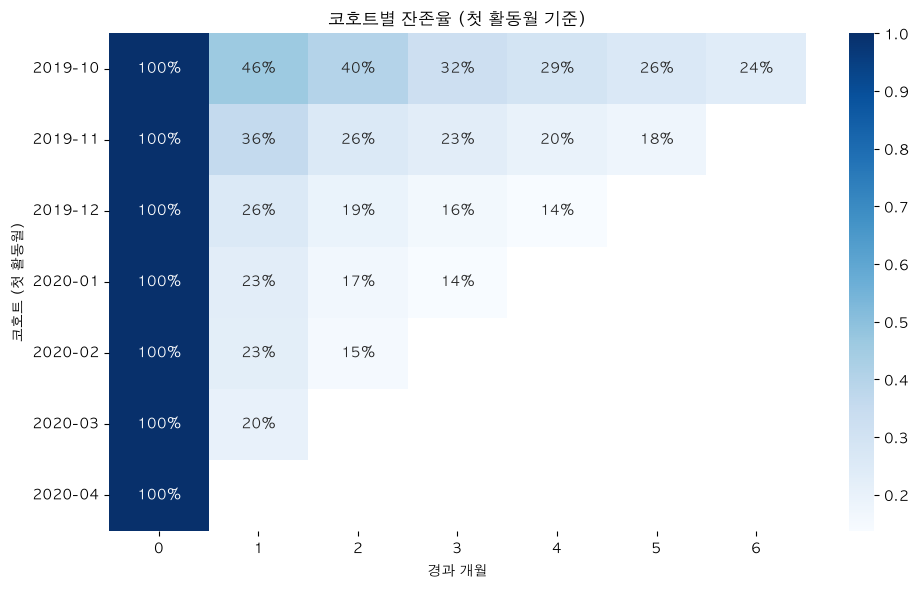

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", mask=retention.isna(), ax=ax)
ax.set_title("코호트별 잔존율 (첫 활동월 기준)")
ax.set_xlabel("경과 개월")
ax.set_ylabel("코호트 (첫 활동월)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "02_cohort_retention_heatmap.png", dpi=150)
plt.show()